## Section 2: Exploratory Data Analysis (EDA)

In [2]:
# define the required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# load the airlines lookup table
airlines = pd.read_csv('Airlines.csv')
airlines.head()

,Code,Description
0,02Q,Titan Airways
1,04Q,Tradewind Aviation
2,05Q,"Comlux Aviation, AG"
3,06Q,Master Top Linhas Aereas Ltd.
4,07Q,Flair Airlines Ltd.


In [4]:
# load the flight dataset
df = pd.read_csv('Combined_Flights_2022.csv')
df.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,...,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",GJT,DEN,False,False,1133,1123.0,0.0,-10.0,...,1140.0,1220.0,8.0,1245,-17.0,0.0,-2.0,1200-1259,1,0
1,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",HRL,IAH,False,False,732,728.0,0.0,-4.0,...,744.0,839.0,9.0,849,-1.0,0.0,-1.0,0800-0859,2,0
2,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,False,False,1529,1514.0,0.0,-15.0,...,1535.0,1622.0,14.0,1639,-3.0,0.0,-1.0,1600-1659,2,0
3,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,GPT,False,False,1435,1430.0,0.0,-5.0,...,1446.0,1543.0,4.0,1605,-18.0,0.0,-2.0,1600-1659,2,0
4,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,False,False,1135,1135.0,0.0,0.0,...,1154.0,1243.0,8.0,1245,6.0,0.0,0.0,1200-1259,2,0


In [5]:
# the Airline column already contains full airline names, so no merge is needed
# drop Code and Description columns if they exist from a previous merge
df = df.drop(columns=[col for col in ["Code", "Description"] if col in df.columns])
df.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,...,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",GJT,DEN,False,False,1133,1123.0,0.0,-10.0,...,1140.0,1220.0,8.0,1245,-17.0,0.0,-2.0,1200-1259,1,0
1,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",HRL,IAH,False,False,732,728.0,0.0,-4.0,...,744.0,839.0,9.0,849,-1.0,0.0,-1.0,0800-0859,2,0
2,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,False,False,1529,1514.0,0.0,-15.0,...,1535.0,1622.0,14.0,1639,-3.0,0.0,-1.0,1600-1659,2,0
3,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,GPT,False,False,1435,1430.0,0.0,-5.0,...,1446.0,1543.0,4.0,1605,-18.0,0.0,-2.0,1600-1659,2,0
4,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,False,False,1135,1135.0,0.0,0.0,...,1154.0,1243.0,8.0,1245,6.0,0.0,0.0,1200-1259,2,0


In [6]:
# show the shape of the dataset
df.shape

(4078318, 61)

In [7]:
# show the data information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4078318 entries, 0 to 4078317
Data columns (total 61 columns):
 #   Column                                   Dtype  
---  ------                                   -----  
 0   FlightDate                               str    
 1   Airline                                  str    
 2   Origin                                   str    
 3   Dest                                     str    
 4   Cancelled                                bool   
 5   Diverted                                 bool   
 6   CRSDepTime                               int64  
 7   DepTime                                  float64
 8   DepDelayMinutes                          float64
 9   DepDelay                                 float64
 10  ArrTime                                  float64
 11  ArrDelayMinutes                          float64
 12  AirTime                                  float64
 13  CRSElapsedTime                           float64
 14  ActualElapsedTime            

In [8]:
# show the data statistics
df.describe()

,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,...,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,DistanceGroup,DivAirportLandings
count,4.078318e+06,3.957885e+06,3.957823e+06,3.957823e+06,3.954079e+06,3.944916e+06,3.944916e+06,4.078318e+06,3.944916e+06,4.078318e+06,...,3.955652e+06,3.955652e+06,3.954076e+06,3.954076e+06,4.078318e+06,3.944916e+06,3.944916e+06,3.944916e+06,4.078318e+06,4.078318e+06
mean,1.329587e+03,1.334374e+03,1.601494e+01,1.309049e+01,1.457886e+03,1.578307e+01,1.110075e+02,1.413211e+02,1.358624e+02,7.978657e+02,...,1.697375e+01,1.356576e+03,1.455073e+03,7.894387e+00,1.486058e+03,7.528486e+00,2.164715e-01,-6.256103e-02,3.663516e+00,3.685098e-03
std,4.904801e+02,5.056219e+02,5.231498e+01,5.332016e+01,5.431841e+02,5.198424e+01,6.996246e+01,7.179635e+01,7.185501e+01,5.914742e+02,...,9.495407e+00,5.075580e+02,5.378428e+02,6.663118e+00,5.185078e+02,5.524625e+01,4.118393e-01,2.487442e+00,2.320848e+00,1.141331e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,-7.800000e+01,1.000000e+00,0.000000e+00,8.000000e+00,-4.800000e+01,1.400000e+01,3.100000e+01,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-1.000000e+02,0.000000e+00,-2.000000e+00,1.000000e+00,0.000000e+00
25%,9.140000e+02,9.170000e+02,0.000000e+00,-5.000000e+00,1.046000e+03,0.000000e+00,6.000000e+01,8.900000e+01,8.300000e+01,3.680000e+02,...,1.100000e+01,9.320000e+02,1.044000e+03,4.000000e+00,1.103000e+03,-1.400000e+01,0.000000e+00,-1.000000e+00,2.000000e+00,0.000000e+00
50%,1.320000e+03,1.325000e+03,0.000000e+00,-2.000000e+00,1.500000e+03,0.000000e+00,9.400000e+01,1.240000e+02,1.190000e+02,6.430000e+02,...,1.500000e+01,1.338000e+03,1.456000e+03,6.000000e+00,1.513000e+03,-5.000000e+00,0.000000e+00,-1.000000e+00,3.000000e+00,0.000000e+00
75%,1.735000e+03,1.744000e+03,1.100000e+01,1.100000e+01,1.914000e+03,1.000000e+01,1.410000e+02,1.710000e+02,1.670000e+02,1.035000e+03,...,1.900000e+01,1.758000e+03,1.909000e+03,9.000000e+00,1.920000e+03,1.000000e+01,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00
max,2.359000e+03,2.400000e+03,7.223000e+03,7.223000e+03,2.400000e+03,7.232000e+03,7.270000e+02,6.900000e+02,7.640000e+02,5.095000e+03,...,2.210000e+02,2.400000e+03,2.400000e+03,2.900000e+02,2.359000e+03,7.232000e+03,1.000000e+00,1.200000e+01,1.100000e+01,9.000000e+00


In [9]:
# check for missing values
df.isnull().sum()

FlightDate                 0
Airline                    0
Origin                     0
Dest                       0
Cancelled                  0
                       ...  
ArrDel15              133402
ArrivalDelayGroups    133402
ArrTimeBlk                 0
DistanceGroup              0
DivAirportLandings         0
Length: 61, dtype: int64

In [10]:
# check for missing values in percentage
df.isnull().mean() * 100

FlightDate            0.000000
Airline               0.000000
Origin                0.000000
Dest                  0.000000
Cancelled             0.000000
                        ...   
ArrDel15              3.271005
ArrivalDelayGroups    3.271005
ArrTimeBlk            0.000000
DistanceGroup         0.000000
DivAirportLandings    0.000000
Length: 61, dtype: float64

## 2.1 Create Flight Status Column

In [11]:
# check the Cancelled and Diverted columns
print(df['Cancelled'].value_counts())
print(df['Diverted'].value_counts())

Cancelled
False    3955126
True      123192
Name: count, dtype: int64
Diverted
False    4068108
True       10210
Name: count, dtype: int64


In [12]:
# create flight_status column from Cancelled, Diverted and DepDelayMinutes
def get_status(row):
    if row['Cancelled'] == True or row['Cancelled'] == 1:
        return 'Cancelled'
    elif row['Diverted'] == True or row['Diverted'] == 1:
        return 'Diverted'
    elif row['DepDelayMinutes'] > 15:
        return 'Delayed'
    else:
        return 'On Time'

df['flight_status'] = df.apply(get_status, axis=1)
df['flight_status'].value_counts()

flight_status
On Time      3113549
Delayed       831367
Cancelled     123192
Diverted       10210
Name: count, dtype: int64

## 2.2 Target Variable Distribution

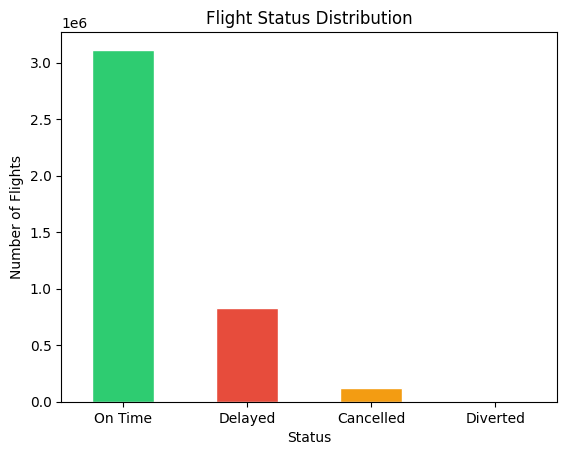

In [13]:
# visualize the flight status distribution
df['flight_status'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'], edgecolor='white')
plt.title('Flight Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Flights')
plt.xticks(rotation=0)
plt.show()

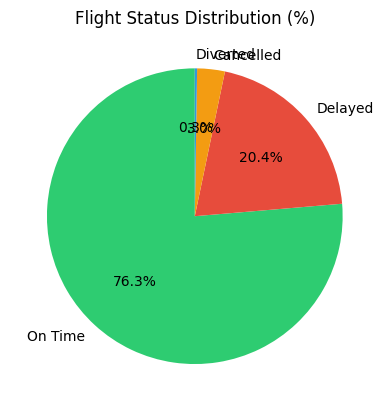

In [15]:
# visualize the flight status as pie chart
df['flight_status'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'], startangle=90)
plt.title('Flight Status Distribution (%)')
plt.ylabel('')
plt.show()

## 2.3 Delay Analysis by Airline

In [16]:
# calculate average delay by airline
airline_delay = df[df['flight_status'] == 'Delayed'].groupby('Airline')['DepDelayMinutes'].mean().sort_values(ascending=False).head(10)
airline_delay

Airline
Mesa Airlines Inc.                           94.492071
SkyWest Airlines Inc.                        90.237108
Commutair Aka Champlain Enterprises, Inc.    89.475450
Capital Cargo International                  88.935469
Endeavor Air Inc.                            88.287216
Air Wisconsin Airlines Corp                  87.125498
GoJet Airlines, LLC d/b/a United Express     86.392605
JetBlue Airways                              82.473507
Comair Inc.                                  81.404149
American Airlines Inc.                       77.731759
Name: DepDelayMinutes, dtype: float64

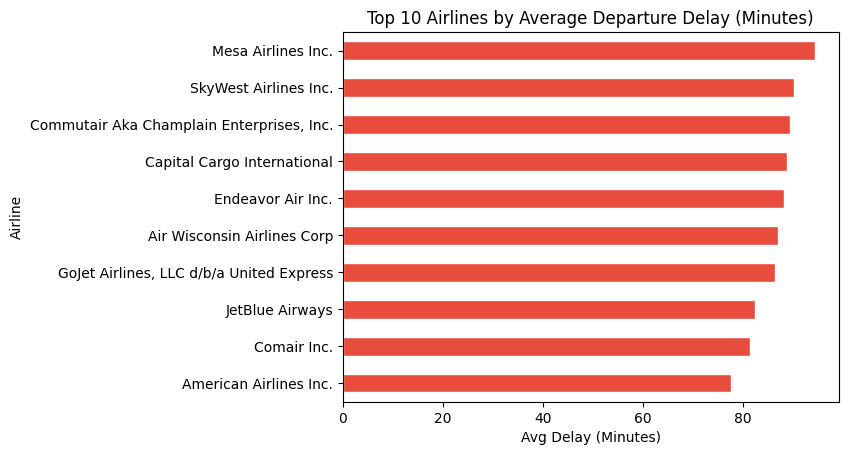

In [17]:
# visualize average delay by airline
airline_delay.plot(kind='barh', color='#e74c3c', edgecolor='white')
plt.title('Top 10 Airlines by Average Departure Delay (Minutes)')
plt.xlabel('Avg Delay (Minutes)')
plt.gca().invert_yaxis()
plt.show()

In [18]:
# calculate delay rate by airline
delay_rate = df.groupby('Airline')['flight_status'].apply(
    lambda x: (x == 'Delayed').sum() / len(x) * 100
).sort_values(ascending=False).head(10)

delay_rate

Airline
JetBlue Airways                             31.837518
Allegiant Air                               29.637843
Frontier Airlines Inc.                      29.633652
Southwest Airlines Co.                      27.479045
Spirit Air Lines                            23.861526
GoJet Airlines, LLC d/b/a United Express    20.754175
American Airlines Inc.                      20.399917
United Air Lines Inc.                       20.274766
Comair Inc.                                 18.764534
Mesa Airlines Inc.                          18.136220
Name: flight_status, dtype: float64

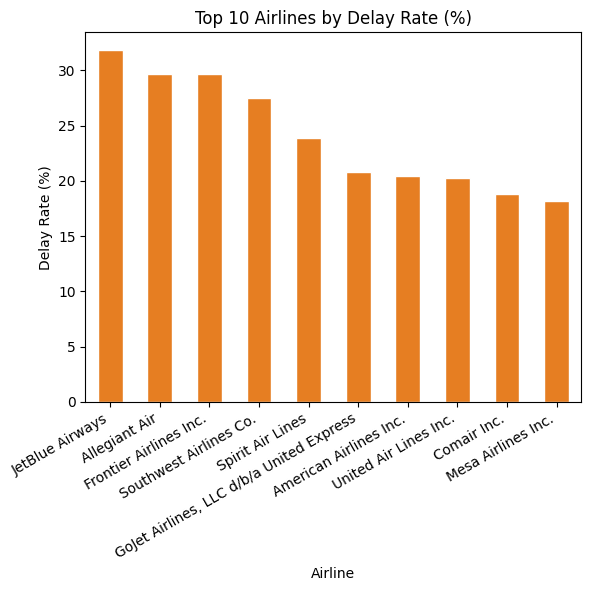

In [19]:
# visualize delay rate by airline
delay_rate.plot(kind='bar', color='#e67e22', edgecolor='white')
plt.title('Top 10 Airlines by Delay Rate (%)')
plt.xlabel('Airline')
plt.ylabel('Delay Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.show()

## 2.4 Delay Trends by Time

In [20]:
# extract departure hour from CRSDepTime
df['DepHour'] = df['CRSDepTime'].astype(str).str.zfill(4).str[:2].astype(int)
df['DepHour'] = df['DepHour'].clip(0, 23)
df['DepHour'].value_counts().sort_index()

DepHour
0       8241
1       2172
2        986
3        766
4        366
5     100526
6     286192
7     272641
8     278757
9     233466
10    265716
11    252654
12    246713
13    251487
14    237345
15    236727
16    232286
17    254154
18    245931
19    213548
20    187142
21    132851
22    106121
23     31530
Name: count, dtype: int64

In [21]:
# calculate delay rate by hour
hourly = df.groupby('DepHour')['flight_status'].apply(lambda x: (x == 'Delayed').sum() / len(x) * 100).reset_index()
hourly.columns = ['Hour', 'Delay_Rate_%']
hourly

,Hour,Delay_Rate_%
0,0,24.135420
1,1,21.869245
2,2,28.194726
3,3,25.195822
4,4,20.491803
5,5,7.718401
6,6,8.478574
7,7,10.533265
8,8,12.420495
9,9,14.484764


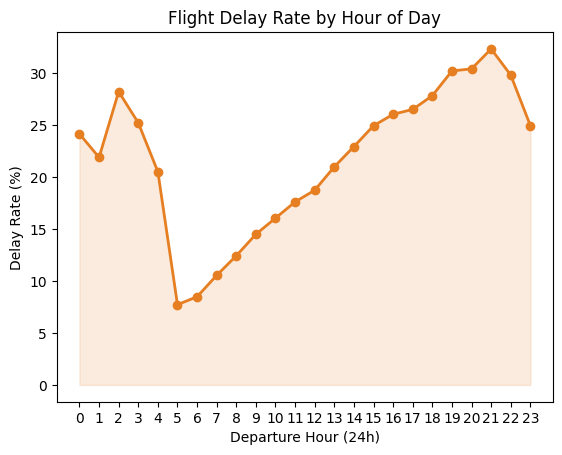

In [22]:
# visualize delay rate by hour of day
plt.plot(hourly['Hour'], hourly['Delay_Rate_%'], marker='o', color='#e67e22', linewidth=2)
plt.fill_between(hourly['Hour'], hourly['Delay_Rate_%'], alpha=0.15, color='#e67e22')
plt.title('Flight Delay Rate by Hour of Day')
plt.xlabel('Departure Hour (24h)')
plt.ylabel('Delay Rate (%)')
plt.xticks(range(0, 24))
plt.show()

In [23]:
# calculate delay rate by month
monthly = df.groupby('Month')['flight_status'].apply(
    lambda x: (x == 'Delayed').sum() / len(x) * 100
).reset_index()
monthly.columns = ['Month', 'Delay_Rate_%']
monthly

,Month,Delay_Rate_%
0,1,17.739478
1,2,18.103594
2,3,20.151996
3,4,20.752210
4,5,19.867485
5,6,22.941183
6,7,22.607670


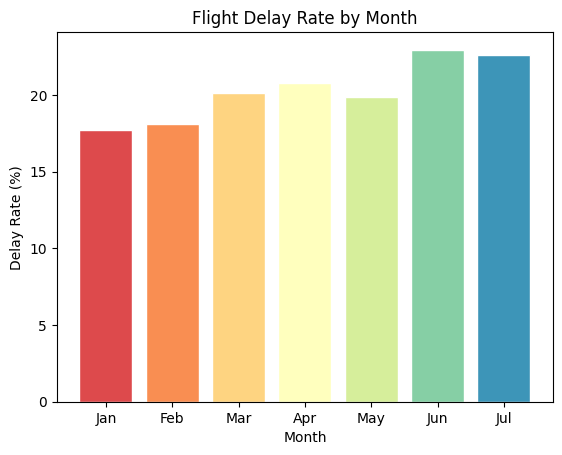

In [24]:
# visualize delay rate by month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['Month_Name'] = monthly['Month'].apply(lambda x: month_names[x-1])

plt.bar(monthly['Month_Name'], monthly['Delay_Rate_%'], color=sns.color_palette('Spectral', len(monthly)), edgecolor='white')
plt.title('Flight Delay Rate by Month')
plt.xlabel('Month')
plt.ylabel('Delay Rate (%)')
plt.show()

In [25]:
# calculate delay rate by day of week
daily = df.groupby('DayOfWeek')['flight_status'].apply(lambda x: (x == 'Delayed').sum() / len(x) * 100).reset_index()
daily.columns = ['DayOfWeek', 'Delay_Rate_%']
daily

,DayOfWeek,Delay_Rate_%
0,1,20.315472
1,2,16.998051
2,3,17.013640
3,4,20.408352
4,5,23.240748
5,6,21.762338
6,7,22.614854


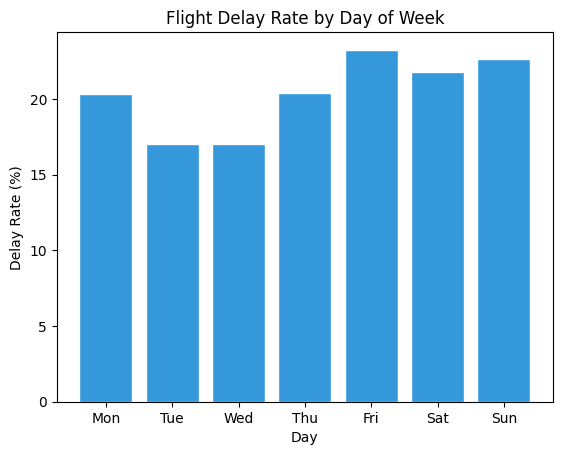

In [26]:
# visualize delay rate by day of week
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
plt.bar(day_names, daily['Delay_Rate_%'], color='#3498db', edgecolor='white')
plt.title('Flight Delay Rate by Day of Week')
plt.xlabel('Day')
plt.ylabel('Delay Rate (%)')
plt.show()

## 2.5 Delay Distribution

In [27]:
# check the departure delay statistics for delayed flights only
df[df['DepDelayMinutes'] > 0]['DepDelayMinutes'].describe()

count    1.558886e+06
mean     4.065999e+01
std      7.711344e+01
min      1.000000e+00
25%      6.000000e+00
50%      1.800000e+01
75%      4.600000e+01
max      7.223000e+03
Name: DepDelayMinutes, dtype: float64

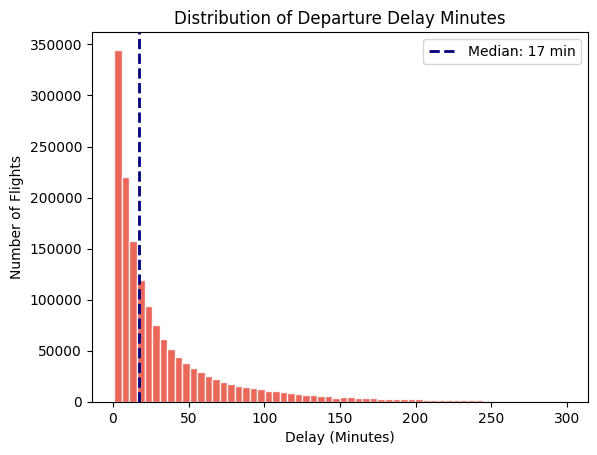

In [28]:
# visualize the distribution of departure delay minutes
delayed_df = df[(df['DepDelayMinutes'] > 0) & (df['DepDelayMinutes'] < 300)]
plt.hist(delayed_df['DepDelayMinutes'], bins=60, color='#e74c3c', edgecolor='white', alpha=0.85)
plt.axvline(delayed_df['DepDelayMinutes'].median(), color='navy', linestyle='--', linewidth=2, label=f"Median: {delayed_df['DepDelayMinutes'].median():.0f} min")
plt.title('Distribution of Departure Delay Minutes')
plt.xlabel('Delay (Minutes)')
plt.ylabel('Number of Flights')
plt.legend()
plt.show()

## 2.6 Correlation Heatmap

In [29]:
# select numerical columns for correlation
num_cols = ['DepDelayMinutes', 'ArrDelayMinutes', 'AirTime', 'Distance', 'TaxiOut', 'TaxiIn']
df[num_cols].corr()

,DepDelayMinutes,ArrDelayMinutes,AirTime,Distance,TaxiOut,TaxiIn
DepDelayMinutes,1.000000,0.980397,0.016387,0.016507,0.044383,0.014994
ArrDelayMinutes,0.980397,1.000000,0.020231,0.010952,0.149370,0.087745
AirTime,0.016387,0.020231,1.000000,0.984916,0.046690,0.075595
Distance,0.016507,0.010952,0.984916,1.000000,0.029227,0.068844
TaxiOut,0.044383,0.149370,0.046690,0.029227,1.000000,0.016307
TaxiIn,0.014994,0.087745,0.075595,0.068844,0.016307,1.000000


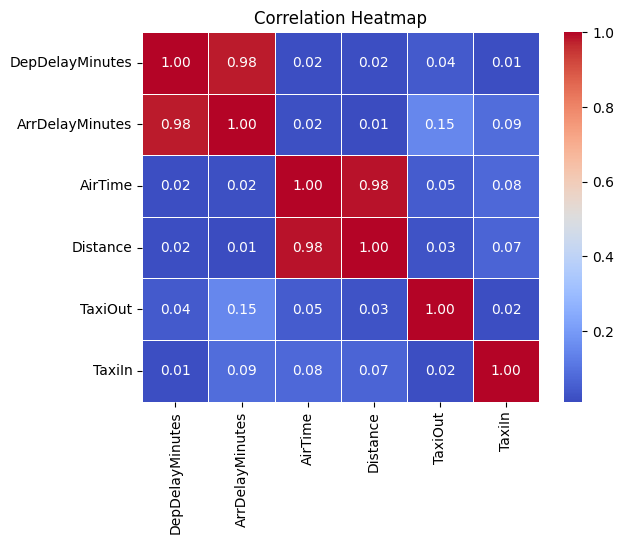

In [30]:
# visualize the correlation heatmap
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## 2.7 Top Routes by Delay

In [31]:
# create route column by combining origin and destination
df['Route'] = df['Origin'] + ' -> ' + df['Dest']
df['Route'].head()

0    GJT -> DEN
1    HRL -> IAH
2    DRO -> DEN
3    IAH -> GPT
4    DRO -> DEN
Name: Route, dtype: str

In [32]:
# calculate average delay by route
route_delay = df[df['flight_status'] == 'Delayed'].groupby('Route')['DepDelayMinutes'].agg(['mean','count']).query('count >= 100').sort_values('mean', ascending=False).head(10)
route_delay

,mean,count
Route,,
COU -> DFW,147.827273,110
ORD -> ASE,146.354167,144
DCA -> PWM,142.380682,176
BRO -> DFW,137.028571,105
OMA -> DTW,136.915094,106
GFK -> MSP,136.488000,125
ROC -> DTW,136.193277,119
BDL -> MIA,132.953271,107
HRL -> DFW,132.215686,102


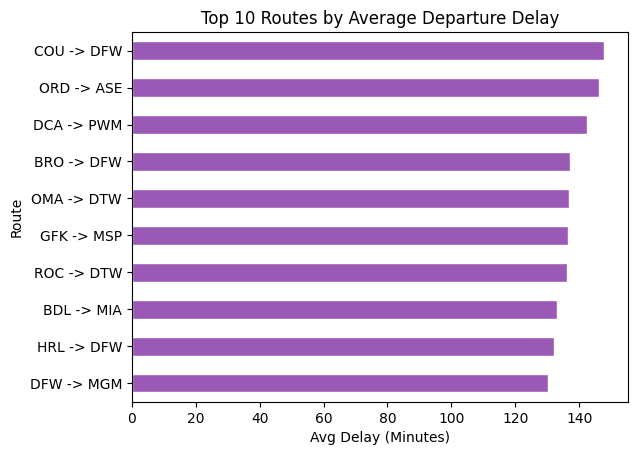

In [33]:
# visualize top 10 routes by average delay
route_delay['mean'].plot(kind='barh', color='#9b59b6', edgecolor='white')
plt.title('Top 10 Routes by Average Departure Delay')
plt.xlabel('Avg Delay (Minutes)')
plt.gca().invert_yaxis()
plt.show()

## Key Insights from EDA

1. **Class Imbalance**: Around 75-80% of flights are On Time. Cancelled flights are less than 3%, which means we need to handle class imbalance during model training.

2. **Departure Delay is the Strongest Signal**: DepDelayMinutes and ArrDelayMinutes are highly correlated. A flight delayed at departure is almost always delayed at arrival.

3. **Evening Cascade Effect**: Delay rate increases throughout the day and peaks around 6-8 PM due to accumulated delays from earlier flights.

4. **Seasonal Peaks**: June, July, and December have the highest delay rates due to peak travel seasons.

5. **Airline Variance**: Different airlines have different delay rates, which means airline is a useful predictor.

6. **Right-skewed Delay Distribution**: Most delays are under 60 minutes but extreme outliers exist.